<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Preface" data-toc-modified-id="Preface-1">Preface</a></span></li><li><span><a href="#Introduction" data-toc-modified-id="Introduction-2">Introduction</a></span></li><li><span><a href="#Sampling" data-toc-modified-id="Sampling-3">Sampling</a></span></li><li><span><a href="#Convolution" data-toc-modified-id="Convolution-4">Convolution</a></span></li><li><span><a href="#Periodic-signals" data-toc-modified-id="Periodic-signals-5">Periodic signals</a></span></li><li><span><a href="#Fourier-series" data-toc-modified-id="Fourier-series-6">Fourier series</a></span></li><li><span><a href="#Fourier-Transform" data-toc-modified-id="Fourier-Transform-7">Fourier Transform</a></span><ul class="toc-item"><li><span><a href="#Continuous-Fourier-Transform" data-toc-modified-id="Continuous-Fourier-Transform-7.1">Continuous Fourier Transform</a></span></li><li><span><a href="#Discrete-Time-Fourier-Transform-(DTFT)" data-toc-modified-id="Discrete-Time-Fourier-Transform-(DTFT)-7.2">Discrete-Time Fourier Transform (DTFT)</a></span></li><li><span><a href="#Discrete-Fourier-Transform-(DFT)" data-toc-modified-id="Discrete-Fourier-Transform-(DFT)-7.3">Discrete Fourier Transform (DFT)</a></span></li></ul></li><li><span><a href="#Convolution-theorem" data-toc-modified-id="Convolution-theorem-8">Convolution theorem</a></span></li><li><span><a href="#Nyquist-Shannon-sampling-theorem" data-toc-modified-id="Nyquist-Shannon-sampling-theorem-9">Nyquist-Shannon sampling theorem</a></span></li><li><span><a href="#Short-time-Fourier-transform" data-toc-modified-id="Short-time-Fourier-transform-10">Short-time Fourier transform</a></span></li><li><span><a href="#Filters" data-toc-modified-id="Filters-11">Filters</a></span><ul class="toc-item"><li><span><a href="#Impulse-response" data-toc-modified-id="Impulse-response-11.1">Impulse response</a></span></li><li><span><a href="#Difference-equation" data-toc-modified-id="Difference-equation-11.2">Difference equation</a></span></li><li><span><a href="#Finite-Impulse-Response-(FIR)-filter" data-toc-modified-id="Finite-Impulse-Response-(FIR)-filter-11.3">Finite Impulse Response (FIR) filter</a></span></li><li><span><a href="#Infinite-Impulse-Response-(IIR)-filter" data-toc-modified-id="Infinite-Impulse-Response-(IIR)-filter-11.4">Infinite Impulse Response (IIR) filter</a></span></li><li><span><a href="#Filter-frequency-response" data-toc-modified-id="Filter-frequency-response-11.5">Filter frequency response</a></span></li></ul></li><li><span><a href="#Postface" data-toc-modified-id="Postface-12">Postface</a></span></li><li><span><a href="#References" data-toc-modified-id="References-13">References</a></span></li></ul></div>

# Preface

This notebook introduces fundamental digital signal processing (DSP) concepts used in the 02471 Machine Learning for Signal Processing course at DTU. It is targeted to students who are not familiar with signal processing and need a resource to catch up. Note that this is however by no means a substitute for the course prerequisites; signal processing is **difficult** and this notebook is far from being exhaustive. Students are invited to check other well established resources when in doubt, or come forward with questions.

If you are reading this from the README.md, I recommend switching the [IPython notebook](https://nbviewer.jupyter.org/github/philgzl/dsp-primer/blob/master/notebook.ipynb) instead, where the math formulas are better rendered. You can also download the notebook to modify and run the code snippets.

The following assumes you are familiar with real analysis mathematics.

# Introduction

In signal processing, a signal usually refers to a time varying function or variable. Signals can be discrete (number of letters) or continuous (pressure, voltage) by nature. In the real world, signals are usually captured by sensors (e.g. a microphone captures pressure variations and converts them to an electrical signal).

A digital signal is a discrete representation of a signal. If the signal is continuous by nature, the digital signal has been derived by sampling and quantization. Digital Signal Processing (DSP) is the analysis and processing of digital signals.

![analog_discrete_digital](pics/analog_discrete_digital.png)

Sampling and quantization is performed by a analog-to-digital converter (ADC). The digital signal can then be processed by DSP processors. Once the signal has been processed, it can be converted back to a continuous signal by a digital-to-analog converter (DAC), if it should be used in the real world. In the real world, ADCs and DACs are widely embedded in many user products.

E.g. the electrical signal produced by the microphone on a laptop is fed to a built-in ADC, and this signal can then be compressed by a DSP processor to be sent over the Internet. Conversely, a DAC converts the digital sound signals to continuous electrical signals so they can be reproduced by the laptop speakers.

A typical signal processing chain is depicted below.

![dsp_chain](pics/dsp_chain.png)

# Sampling

In math terms, the sampling of a continuous signal can be described as follows. Let $x(t)$ a continuous signal,

$$
\begin{aligned}
x \colon \mathbb{R} &\longrightarrow \mathbb{R} \\
t &\longmapsto x(t).
\end{aligned}
$$

A digital representation of $x(t)$ noted $x[n]$ can be defined as follows,

$$ x[n] = x(nT_s) , \quad \forall n \in \mathbb{Z}, $$

where $T_s$ is the **sampling period**. The smaller $T_s$, the finer and more accurate the digital representation of the signal, but also the heavier the representation. The sampling operation is more commonly characterized by the sampling frequency (or sampling rate) $f_s$,

$$ f_s = \frac{1}{T_s}.$$

**Example**: common audio sampling frequencies are 8 kHz (telecommunications), 44.1 kHz (music CDs) and 48 kHz (movie tracks).

**Note**: In signal processing, notations like $x(t)$ are widely used to refer to a continuous signal or function, without introducing $t$. In other words, $x(t)$ does not refer to the value taken by $x$ at $t$, but refers to the function $x$ of the dependent variable $t$. Similarly, $x[n]$ refers to the function defined on the discrete domain. The usage of brackets is widely used to distinguish discrete signals from analog signals.

**Note**: the signals above were introduced as taking values in $\mathbb{R}$ but they can also take values in $\mathbb{C}$.

The sampling of a continuous signal can be described in the continuous domain by using the product of the original signal with a special function. Consider the following function called **Dirac comb** with period $T_s$,

$$
\begin{aligned}
\text{III}_{T_s} \colon \mathbb{R} &\longrightarrow \mathbb{R} \\
t &\longmapsto \sum_{k=-\infty}^{+\infty}\delta(t-kT_s),
\end{aligned}
$$

where $\delta$ is the Dirac delta function. In other words, $\text{III}_{T_s}$ is the function that equals zero everywhere except on points evenly spaced by $T_s$.

![comb](pics/comb.png)

Sampling $x(t)$ can be seen as multiplying $x(t)$ with $\text{III}_{T_s}$,

$$
\forall t \in \mathbb{R}, \quad (\text{III}_{T_s} x)(t) = \left\{
\begin{aligned}
&x(n{T_s}) &&\text{if}\ \exists n \in \mathbb{Z}\ \text{such that}\ t=n{T_s},\\
&0 &&\text{else}.
\end{aligned}\right.
$$

This will show useful later on.

# Convolution

The convolution is a mathematical operation between two functions and outputs a new function. It is a fundamental tool in signal processing. The convolution operator is noted $*$ and it is well defined for integrable functions in $L^1(\mathbb{R})$,

$$
\begin{aligned}
* \colon L^1(\mathbb{R}) \times L^1(\mathbb{R}) &\longrightarrow L^1(\mathbb{R}) \\
f, g &\longmapsto f * g
\end{aligned}
$$

It is defined as follows:

$$ \forall \tau \in \mathbb{R}, \quad (f * g)(\tau) = \int_{-\infty}^{+\infty}f(t)g(\tau-t)dt. $$

The convolution is commutative: $f * g = g * f$.

The **discrete convolution** is the adaptation to discrete signals and is defined as follows:

$$ \forall m \in \mathbb{Z}, \quad (f * g)[m] = \sum_{n=-\infty}^{+\infty}f[n]g[m-n]. $$

For discrete signals with finite lengths, signal values outside the definition range are assumed to be 0, and the sum becomes finite as most of the terms equal zero. E.g. if $x[n]$ with length $N_x$ is defined for $n \in \{0, 1, ..., N_x-1\}$, and $y[n]$ with length $N_y$ is defined for $n \in \{0, 1, ..., N_y-1\}$, then $(x * y)[m]$ has length $N_x+N_y-1$ and is defined for  $m \in \{0, 1, ..., N_x+N_y-1\}$.

I am introducing this operation here as it is fundamental tool in DSP and it will be used later on.

The best way the understand this operation is to look at a visual representation. The convolution can be summarized as an inversion of one of the signals, followed by a "delay-and-product-sum" operation; for each delay value $\tau$ or $m$, one signal is delayed with respect to the other before integrating the product of the signals. See the animation below. The convolution result $f*g$ in black is obtained by integrating the green area at each time step.

![convolution](pics/convolution.gif)

**Example**: The identity element for the convolution is the Dirac delta impulse,

$$x[n] * \delta[n] = x[n]. $$

You can try to prove it as an exercise.

**Example**: The L-point moving average of a time series can be expressed as a convolution. Consider $x[n]$ a time series and $y[n]$ its L-point moving average,

$$ 
\begin{aligned}
y[n] &= \frac{1}{L}(x[n] + x[n-1] +\ ...\ + x[n-L+1])\\
&= \frac{1}{L}\sum_{k=0}^{L-1}x[n-k]\\
&= \sum_{k=0}^{L-1}h[k]x[n-k] \quad \quad \text{where}\ h[k]=\frac{1}{L}\\
&= h[n]*x[n],
\end{aligned}
$$

where $h[n]=\underbrace{[\frac{1}{L}, \frac{1}{L},\ ...\ , \frac{1}{L}]}_\text{L terms}$.

Below I use `numpy.convolve` to convolve an arbitrary signal with $h[n]=[\frac{1}{L}, \frac{1}{L},\ ...\ , \frac{1}{L}]$.

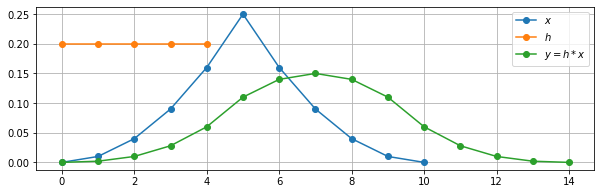

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['axes.grid'] = True

n = 11  # number of points
x = np.linspace(0, 1, n)**2 ; x = np.minimum(x, x[::-1])  # arbitrary signal
L = 5  # number of points to average
h = np.ones(L)/L
y = np.convolve(h, x)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x, 'o-', label='$x$')
ax.plot(h, 'o-', label='$h$')
ax.plot(y, 'o-', label='$y=h*x$')
ax.legend()
plt.show()

# Periodic signals

Let $x(t)$ a periodic signal. Therefore, there exists a period $T\in\mathbb{R}$ such that

$$ x(t+T) = x(t), \quad \forall t \in \mathbb{R}. $$

A periodic signal can also be characterized by its frequency $f$,

$$ f = \frac{1}{T}. $$

Examples of periodic signals:
* Sinusoids: $ x(t) = \sin(2 \pi f t), \forall t \in \mathbb{R} $
* Complex exponentials: $ x(t) = e^{i 2 \pi f t}, \forall t \in \mathbb{R} $
* Temperature across seasons (roughly, and disregarding rising trend due to global warming)

# Fourier series

Any continuous periodic signal can be written as a discrete sum of complex exponentials called Fourier series.

Let $x(t)$ be a periodic signal with period $T$. Therefore, there exists a sequence $c_n$ in $\mathbb{C}$ such that

$$ x(t) = \sum_{n=-\infty}^{+\infty} c_n e^{i 2 \pi \frac{n t}{T}}, \quad \forall t \in \mathbb{R}. $$

The $c_n$ are called the **Fourier coefficients**.

If $x(t)$ is real-valued, then for all $n \in \mathbb{Z}$, $c_n$ and $c_{-n}$ are complex conjugates and the sum can be rearranged as a sum of sines and cosines,

$$ x(t) = \frac{a_0}{2} + \sum_{n=1}^{+\infty} a_n \cos (2 \pi \frac{n t}{T}) + \sum_{n=1}^{+\infty} b_n \sin (2 \pi \frac{n t}{T}) , \quad \forall t \in \mathbb{R}. $$

This property is very powerful as it means that we can think of any periodic signal as a sum of well-known functions, the complex exponentials. Moreover, as you may know from your real analysis course, the complex exponentials form a **basis** of functions in the $L^2$ sense. This means that the $c_n$ can be derived by projecting $x(t)$ onto the individual basis functions,

$$ c_n = \frac{1}{T}\int_T x(t) e^{-i 2 \pi \frac{n t}{T}} dt, \quad \forall n \in \mathbb{Z}.$$

The Fourier series are a primary motivation of the **Fourier transform** (see later).

**Example**: Let $x(t)$ a sine function with frequency $f$,

$$ x(t) = \sin(2 \pi f t), \quad \forall t \in \mathbb{R}.$$

Euler's formula allows to rewrite $x(t)$ as

$$ x(t) = -\frac{i}{2}e^{i 2 \pi f t} + \frac{i}{2}e^{-i 2 \pi f t}, \quad \forall t \in \mathbb{R}.$$

Here the Fourier coefficients can be directly identified. We have
* $c_1 = -\frac{i}{2}$,
* $c_{-1} = \frac{i}{2}$,
* $c_n = 0$ if $n \notin \{-1, 1\}$.

**Example**: Let $x(t)$ a sawtooth wave with period $2 \pi$,

$$ x(t) = (\frac{t}{\pi} + 1)\ \text{mod}\ 2 - 1, \quad \forall t \in \mathbb{R}.$$

It can be shown that $x(t)$ can be rewritten as an infinite sum of sines,

$$ x(t) = -\frac{2}{\pi}\sum_{k=1}^{+\infty}\frac{(-1)^k}{k}\sin kt.$$

The Fourier coefficients here are

* $c_k = \frac{i}{\pi}\frac{(-1)^k}{k}$ if $k>0$,

* $c_k = -\frac{i}{\pi}\frac{(-1)^k}{k}$ if $k<0$,

* $c_0 = 0$ if $k=0$.

Or using $a_n$ and $b_n$ coefficients,

* $b_k = -\frac{2}{\pi}\frac{(-1)^k}{k}$ for all $k>0$,

* $a_k = 0$ for all $k\geq 0$.

In the snippet below I verify this by adding a finite amount of these sines. We can see the more sines are added, the more the total sum resembles a sawtooth wave.

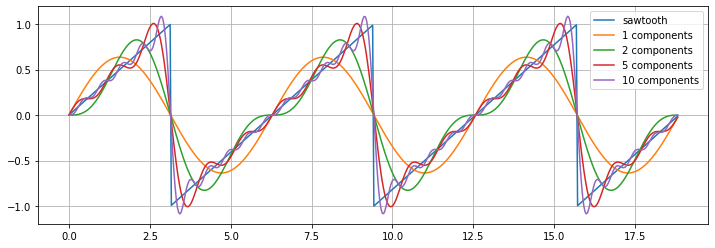

In [2]:
n = 500  # number of points
n_T = 3  # number of periods

t = np.arange(n)/n*n_T*2*np.pi
x = (t/np.pi + 1) % 2 - 1

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, x, label='sawtooth')

for n_components in [1, 2, 5, 10]:
    x = 0
    for k in range(1, n_components+1):
        x += -2/np.pi*(-1)**k/k*np.sin(k*t)
    ax.plot(t, x, label=f'{k} components')

ax.legend()
plt.show()  # you should see the more sines we add, the closer the total sum resembles a sawtooth wave

# Fourier Transform

## Continuous Fourier Transform

The Fourier transform is a mathematical operation that decomposes functions depending on time into functions depending on frequency. The term *Fourier transform* can refer to both the frequency domain representation of a signal and the mathematical operation itself.

The Fourier transform is first formally defined for continuous signals (not necessarily periodic) and outputs a new continuous function depending on frequency. It is commonly noted $\mathcal{F}$ and is defined as

$$
\begin{aligned}
\mathcal{F} \colon L^1(\mathbb{R}) &\longrightarrow L^1(\mathbb{R}) \\
f &\longmapsto
\begin{aligned}[t]
    \mathcal{F}(x) \colon \mathbb{R} &\longrightarrow \mathbb{C} \\
    \omega &\longmapsto \int_{-\infty}^{+\infty}x(t)e^{-i\omega t}dt.
\end{aligned}
\end{aligned}
$$

In other words, given $x$ a continuous function depending on time,

$$ \mathcal{F}(x)(\omega) = \int_{-\infty}^{+\infty}f(t)e^{-i\omega t}dt, \quad \forall \omega \in \mathbb{R}. $$

This can be seen as the projection of $x$ onto the basis of complex exponentials.

A few notes/properties:
* The Fourier transform of $x$ is a function of $\omega$ which is a **frequency variable** in radian per second (rad/s). Sometimes, a frequency variable in Hertz and noted $f$ is used instead. In which case, $\omega=2\pi f$ and the integral is changed accordingly.
* The Fourier transform takes **complex** values
* The Fourier transform is **linear**: $\mathcal{F}(\alpha x + \beta y)=\alpha\mathcal{F}(x)+\beta\mathcal{F}(y)$
* It is common to note the Fourier transform of $x$ with an uppercase like this: $\mathcal{F}(x)=X$.
    * Sometimes it is noted like this to emphasize on the dependent variable: $\mathcal{F}[x(t)] = X(\omega)$
* The inverse Fourier transform of X is $$ \mathcal{F}^{-1}(X)(t) = \frac{1}{2\pi}\int_{-\infty}^{+\infty}X(\omega)e^{i\omega t}d\omega, \quad \forall t \in \mathbb{R}, $$ which is the same as the forward Fourier transform except there is a normalization factor and a plus sign in the exponential.

This was all in the continuous domain so far. Now, there is as rigorous formalism that I will skip that allows to adapt the continuous Fourier transform to digital signals while keeping *most* of its properties. We first define the discrete-time Fourier transform (DTFT), and then the discrete Fourier transform (DFT). I will go over this quickly without diving into the intricacies about how the validity of the properties is kept. But the properties are overall maintained and the underlying mechanism of all the Fourier transform variants is the same: we decompose signals into frequencies.

If you wish a more complete explanation of steps between Fourier transform, DTFT and DFT, you can refer to [Proakis and Manolakis](#References), Chapters 4 and 7.

## Discrete-Time Fourier Transform (DTFT)

Let $x[n]$ a discrete signal with infinite length (not necessarily periodic). The discrete-time Fourier transform (DTFT) of $x[n]$ is defined as

$$ X(\omega) = \sum_{n=-\infty}^{+\infty}x[n]e^{-i\omega n}, \quad \forall \omega \in \mathbb{R}.$$

Again, this resembles a projection on the basis of complex exponentials, except it was adapted for a discrete signal by replacing the integration sign with a discrete sum over the signal values.

The DTFT is $2\pi$ periodic. The inverse DTFT is

$$ x[n] = \frac{1}{2\pi}\int_{2\pi}X(\omega)e^{i\omega n}d\omega, \quad \forall n \in \mathbb{Z}.$$

This is a first adaptation for discrete signals, except the summation is infinite and it still takes values in an infinite and continuous frequency space. The next step is to *truncate* and *sample* the DTFT at equidistant frequency points, which yields the discrete Fourier transform (DFT).

## Discrete Fourier Transform (DFT)

Let $x[n]$ a discrete signal of finite length $N$. That is, we have a sequence of $N$ values $x[0], x[1], ..., x[N-1]$. The discrete Fourier transform (DFT) of $x[n]$ is defined as

$$ X[k] = \sum_{n=0}^{N-1}x[n]e^{-i 2 \pi \frac{kn}{N}}, \quad \forall k \in \{0, 1, ..., N-1\}.$$

The inverse DFT is

$$ x[n] = \frac{1}{N}\sum_{k=0}^{N-1}X[k]e^{i 2 \pi \frac{kn}{N}}, \quad \forall n \in \{0, 1, ..., N-1\}.$$

The DFT takes as input a discrete and finite amount of values and outputs a discrete and finite amount of values, so it can be evaluated using computers, unlike the DTFT. Below is a table with an overview of the different transforms.

![transforms](pics/transforms.png)

The discrete Fourier transform plays a huge role in DSP, and while the math theory behind can be difficult to fully grasp, it is absolutely essential to understand the gist of it: **it decomposes signals into frequencies**. The frequency components are best observed by plotting the (squared) modulus of the Fourier transform. The modulus of the Fourier transform is often referred to as **magnitude spectrum**, and the analysis of signals using the Fourier transform as **spectral analysis**. The phase information is more difficult to interpret and can be disregarded for this course.

The DFT is implemented in `numpy` under `numpy.fft.fft`. FFT stands for Fast Fourier Transform and is an optimized algorithm to calculate the DFT. The terms FFT and DFT are often used interchangeably.

**Example**: Let's create a simple signal consisting of a sum of 2 sinusoids with different frequencies. You will see how the DFT is able to resolve the 2 components.

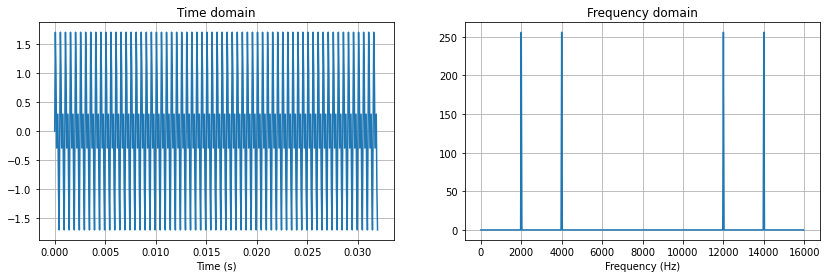

In [3]:
n = 512  # number of points
fs = 16e3  # sampling frequency

f1 = 2000  # frequency of the first component
f2 = 4000  # frequency of the second component

t = np.arange(n)/fs  # time axis
x = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t)  # time-domain signal
X = np.fft.fft(x)  # DFT
f = np.arange(n)/n*fs  # frequency axis; see details further below

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(t, x)
axes[0].set_title('Time domain')
axes[0].set_xlabel('Time (s)')
axes[1].plot(f, np.abs(X))  # we plot the magnitude as X is complex
axes[1].set_title('Frequency domain')
axes[1].set_xlabel('Frequency (Hz)')

plt.show()  # you should see two clean spikes at locations corresponding to f1 and f2
# you should also see two extra spikes at fs-f1 and fs-f2; see details further below

A few practical notes here already:
* The DFT output is **two-sided**. Half of it's values correspond to **negative** frequencies. This makes sense for complex-valued signals, but for real-valued signals, opposite frequencies are conjugates and the information is thus redundant. It is thus common to **crop half of the FFT output**. You can also check the documentation for `numpy.fft.rfft` for more details, which outputs a one-sided signal already.
* Building the frequency vector axis for the output can be confusing. However you should keep in mind this: **the resolution in the frequency domain is always $\frac{f_s}{N}$**, where $f_s$ is the sampling frequency and $N$ is the number of points.
    * This means that increasing $f_s$ gives a worse resolution in the frequency domain. **A finer resolution in the time domain means a coarser resolution in the frequency domain**. This is known as the **time-frequency duality**.
    * The frequency values corresponding to the raw FFT output are ordered as follows:
        * if N is even:

        $$ 0,\ \frac{f_s}{N},\ ...,\ \frac{N}{2}\frac{f_s}{N},\ (-\frac{N}{2}+1)\frac{f_s}{N},\ ...,\ -\frac{f_s}{N}$$

        * if N is odd:

        $$ 0,\ \frac{f_s}{N},\ ...,\ \frac{N-1}{2}\frac{f_s}{N},\ -\frac{N-1}{2}\frac{f_s}{N},\ ...,\ -\frac{f_s}{N}$$

      Yes, we first have the positive frequencies in increasing order up to $\frac{f_s}{2}$, and then the negative frequencies increasing from $-\frac{f_s}{2}$ to 0. These frequency values are commonly called **frequency bins**, as if the energy was falling in *bins* centered at those frequencies. 

FAQ:
* *But you drew positive frequencies in the frequency-domain plot above up to $\frac{f_s}{2}$!*
    * Yes, this was just to show how the raw FFT output is ordered, and I didn't rename half of the x-axis ticks to avoid too much confusion. If you don't want to crop half of the FFT nor use `numpy.fft.rfft` and want to plot the entire spectrum including negative frequencies, then you would replace the positive frequencies above $\frac{f_s}{2}$ with the negative frequencies listed above and eventually flip the two halves such that the values increase from -$\frac{f_s}{2}$ to $\frac{f_s}{2}$. You can also check `numpy.fft.fftshift`.
* *What about the frequencies above $\frac{f_s}{2}$ contained in the signal then?*
    * If the sampling frequency is $f_s$, then the maximum representable frequency in the digital signal is $\frac{f_s}{2}$. In other words, if a continuous signal is sampled at a sampling frequency $f_s$, then all the information at frequencies above $\frac{f_s}{2}$ is **lost**. This is the **Nyquist-Shannon sampling theorem** and I will detail it further below. I didn't introduce the sampling theorem yet because I wanted to introduce the convolution and the FFT before to better explain it.
* *Considering if $N$ is even or odd is tedious... How can I easily and consistently build the frequency vector axis correctly?*
    * I do as follows:
        * I remember the resolution is always $\frac{f_s}{N}$ and build the entire frequency vector of length $N$ including the frequencies above $\frac{f_s}{2}$ (or negative frequencies): `f = np.arange(n)/n*fs`
        * I find the frequencies strictly above $\frac{f_s}{2}$: `mask = f > fs/2`
            * If I want a one-sided spectrum I discard them: `f = f[~mask]`
            * If I want a two-sided spectrum I subtract $f_s$ to them: `f[mask] -= fs`
      
      This will consistently give a correct frequency axis regardless of $N$ being even or odd. You can also use the `numpy.fft.fftfreq` or `np.fft.rfftfreq` functions.

**More examples**: Below I plot a series of common Fourier transforms.

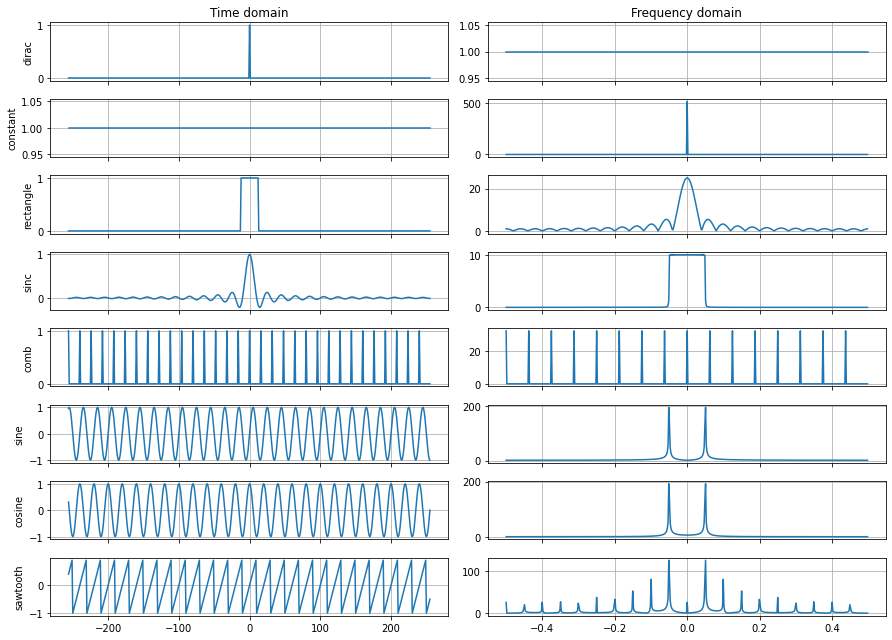

In [4]:
n_rows = 8
fig, axes = plt.subplots(n_rows, 2, figsize=(12.5, 9))
axes[0, 0].set_title('Time domain')
axes[0, 1].set_title('Frequency domain')
for row in range(n_rows-1):
    axes[row, 0].set_xticklabels([])
    axes[row, 1].set_xticklabels([])

n = 512
t = np.arange(n) - n//2
f = np.fft.fftfreq(n); f = np.fft.fftshift(f)

def plot_row(row, x, ylabel):
    X = np.fft.fft(x); X = np.fft.fftshift(X)
    axes[row, 0].plot(t, x)
    axes[row, 1].plot(f, abs(X))
    axes[row, 0].set_ylabel(ylabel)

# dirac
x = np.zeros(n); x[n//2] = 1
plot_row(0, x, 'dirac')

# constant
x = np.ones(n)
plot_row(1, x, 'constant')

# rectangle
x = abs(t) < n*0.025
plot_row(2, x, 'rectangle')

# sinc
x = np.sinc(t*0.1)
plot_row(3, x, 'sinc')

# comb
x = np.zeros(n); x[t%(n//32)==0] = 1
plot_row(4, x, 'comb')

# sine
x = np.sin(2*np.pi*t*0.05)
plot_row(5, x, 'sine')

# cosine
x = np.cos(2*np.pi*t*0.05)
plot_row(6, x, 'cosine')

# sawtooth
x = (t*0.1 + 1) % 2 - 1
plot_row(7, x, 'sawtooth')

fig.tight_layout()
plt.show()

A few important Fourier transforms (FT) to note here:
* The FT of a Dirac impulse is an infinitely-long rectangular window. Conversely, the FT of an infinitely-long rectangular window is a Dirac impulse.
    * This again has to do with the **time-frequency duality**. A signal that is very narrow in time is very broad in frequency. Conversely, a signal that is very localized in frequency is very broad in time.
* The FT of a rectangular window is a sinc function (the time-domain plot is the absolute value which is why it's not exactly a sinc). Conversely, the FT of a sinc function is a rectangular window.
    * In accordance with the time-frequency duality, the narrower the rectangular window in one domain, the wider the sinc function in the other domain.
* The FT of a Dirac comb is also a Dirac comb!
    * This will show useful when explaining the Nyquist-Shannon sampling theorem further below.
* The FT of the sawtooth signal shows decaying spikes equally spaced at multiples of the fundamental frequency, in accordance with the Fourier series expression introduced further above!

# Convolution theorem

The convolution theorem states that convolution in the time-domain is the same as multiplication in the frequency domain. Conversely, multiplication in the time-domain is the same as convolution in the frequency domain.

In the continuous case, let $x(t)$ and $y(t)$ two signals in $L^1(\mathbb{R})$. With $\mathcal{F}$ the Fourier transform operator for continuous functions, and $*$ the continuous convolution operator, we have

$$ \mathcal{F}(x*y) = \mathcal{F}(x)\mathcal{F}(y), $$
$$ \mathcal{F}(xy) = \frac{1}{2\pi}\mathcal{F}(x)*\mathcal{F}(y). $$

This is quite powerful as it means we can decide to derive a convolution, which is usually an expensive operation, in the frequency domain instead. Indeed, an immediate consequence is

$$ x*y = \mathcal{F}^{-1}(\mathcal{F}(x)\mathcal{F}(y)). $$

This means we can perform a multiplication in the frequency domain and use back and forth Fourier transforms between the time and frequency domains to obtain the same result as a convolution in the time domain.

Now for discrete signals, let $x[n]$ and $y[n]$ two signals of length $N$. With $\mathcal{F}$ the DFT operator and $*$ the discrete convolution operator, we have

$$ \mathcal{F}(x*y) = \mathcal{F}(x)\mathcal{F}(y), $$
$$ \mathcal{F}(xy) = \frac{1}{N}\mathcal{F}(x)*\mathcal{F}(y). $$

Note that if $x[n]$ and $y[n]$ do not have same length, we can simply zero-pad the shorter signal until lengths are the same, such that point-wise multiplication is possible.

In the snippet below I attempt to verify both properties.

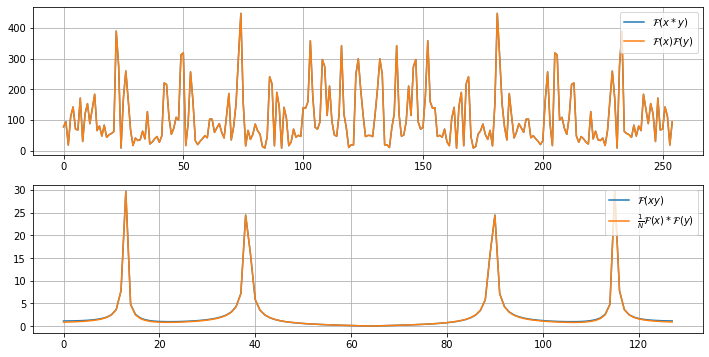

In [5]:
n = 128  # number of points

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# first property: F(x*y)=F(x)F(y)
x = np.random.randn(n)
y = np.random.randn(n)
z = np.convolve(x, y)

X = np.fft.fft(x, n=len(z))  # forcing the FFT output to be same length as z
Y = np.fft.fft(y, n=len(z))  # forcing the FFT output to be same length as z

Z1 = np.fft.fft(z)
Z2 = X*Y

axes[0].plot(abs(Z1), label=r'$\mathcal{F}(x*y)$')
axes[0].plot(abs(Z2), label=r'$\mathcal{F}(x)\mathcal{F}(y)$')
axes[0].legend(loc='upper right')

# second property: F(xy)=F(x)*F(y)
# this one is a bit trickier as we need to flip the FFTs before convolving
# we also need to filter out all the extra frequencies resulting from the convolution in the frequency domain
x = np.sin(2*np.pi*np.arange(n)*0.3)  # using random noise here does not give perfect result
y = np.sin(2*np.pi*np.arange(n)*0.1)  # using random noise here does not give perfect result
z = x*y

X = np.fft.fft(x)
Y = np.fft.fft(y)
X = np.fft.fftshift(X)  # flip before convolving
Y = np.fft.fftshift(Y)  # flip before convolving

Z1 = np.fft.fft(z)
Z1 = np.fft.fftshift(Z1)
Z2 = np.convolve(X, Y)/n
Z2 = Z2[n//2:-n//2+1]  # discard extra frequencies created from the convolution

axes[1].plot(abs(Z1), label=r'$\mathcal{F}(xy)$')
axes[1].plot(abs(Z2), label=r'$\frac{1}{N}\mathcal{F}(x)*\mathcal{F}(y)$')
axes[1].legend(loc='upper right')

plt.show()  # you should observe the curves overlap in both plots

# Nyquist-Shannon sampling theorem

Briefly put, when sampling at a frequency $f_s$, the sampling theorem says that the highest representable frequency is $\frac{f_s}{2}$. In other words, the sampling frequency should be at least twice as high as the highest frequency component of the sampled signal.

A simple example to illustrate this is the sampling of a sinusoid. Consider a sinusoid with frequency $f_0=100\ \text{Hz}$ sampled at a different frequencies $f_s$.

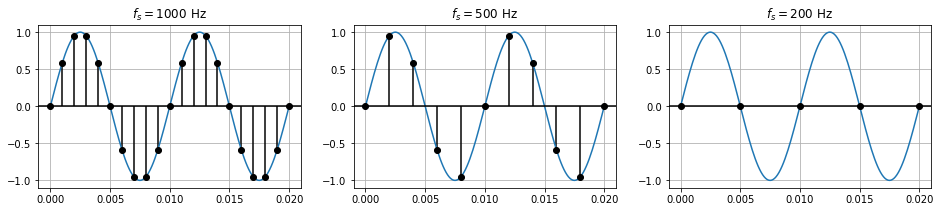

In [6]:
f0 = 100  # sinusoid frequency
T = 2e-2  # sinusoid duration in seconds

# first create a sinusoid with a fine time step; this will represent the continuous signal
fs_hi = 8e3  # high sampling frequency
t_cont = np.arange(0, T+1/fs_hi, 1/fs_hi)  # fine time vector with time step 1/fs
x_cont = np.sin(2*np.pi*f0*t_cont)  # this represents the continuous signal

fig, axes = plt.subplots(1, 3, figsize=(16, 3))

# now let's create a coarse digital signals for different low sampling frequencies
for ax, fs_lo in zip(axes, [1000, 500, 200]):
    ax.plot(t_cont, x_cont)
    t_coarse = np.arange(0, T+1/fs_lo, 1/fs_lo)
    x_coarse = np.sin(2*np.pi*f0*t_coarse)
    ax.stem(t_coarse, x_coarse, 'k', markerfmt='ko', basefmt=' ')
    ax.axhline(0, color='k')
    ax.set_title(f'$f_s={fs_lo}$ Hz')

plt.show()

Can you see where the problem arises once we set $f_s$ below $2f_0=200\ \text{Hz}$? It will not be possible to reconstruct the continuous signal anymore from the digital signal. To see why, imagine $f_s=180\ \text{Hz}$ and we have two sinusoids, one at $f_0=100\ \text{Hz}$ and $f_1=80\ \text{Hz}$.

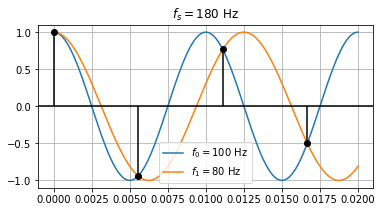

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))

f0 = 100
f1 = 80

x_cont = np.cos(2*np.pi*f0*t_cont)
ax.plot(t_cont, x_cont, label=f'$f_0={f0}$ Hz')

x_cont = np.cos(2*np.pi*f1*t_cont)
ax.plot(t_cont, x_cont, label=f'$f_1={f1}$ Hz')

fs_lo = 180
t_coarse = np.arange(0, T, 1/fs_lo)
x_coarse = np.cos(2*np.pi*f0*t_coarse)
ax.stem(t_coarse, x_coarse, 'k', markerfmt='ko', basefmt=' ')
ax.axhline(0, color='k')

ax.set_title(f'$f_s={fs_lo}$ Hz')
ax.legend()

plt.show()

As you can see, both signals produce the exact same samples! It's therefore impossible to know from the samples if the signal is a sinusoid at 80 Hz or a sinusoid at 100 Hz.

This can be explained in the general case of any signal using the convolution theorem and the Dirac comb function. Remember we saw above that sampling is the same as multiplying the signal with the Dirac comb,

$$
\forall t \in \mathbb{R}, \quad (\text{III}_{T_s} x)(t) = \left\{
\begin{aligned}
&x(n{T_s}) &&\text{if}\ \exists n \in \mathbb{Z}\ \text{such that}\ t=n{T_s},\\
&0 &&\text{else},
\end{aligned}\right.
$$

where $T_s=\frac{1}{f_s}$ is the sampling period. The convolution theorem gives us that the Fourier transform of a product is the convolution of the Fourier transforms in the frequency domain:

$$\mathcal{F}(\text{III}_{T_s} x) = \mathcal{F}(\text{III}_{T_s})*\mathcal{F}(x) = \mathcal{F}(\text{III}_{T_s})*X$$

Now it can be shown that the Fourier transform of a Dirac comb is also a Dirac comb (you can try to prove it, it's a cool exercise) with period $\omega_s=2\pi f_s$,

$$\forall\omega\in\mathbb{R},\quad\mathcal{F}(\text{III}_{T_s})(\omega)=\text{III}_{\omega_s}(\omega)=\omega_s\sum_{k=-\infty}^{+\infty}\delta(\omega-\omega_s)$$

Therefore, sampling in the time-domain is the same as convolving with a Dirac comb in the frequency domain. And convolving with a Dirac comb is the same as replicating the signal infinitely, with replicas evenly spaced by $\omega_s$.

The image below describes this. In the image, $X_a(\omega)$ is an example spectrum of the original continuous signal $x(t)$, while $X_\delta(\omega)$ is the spectrum of the sampled signal $(\text{III}_{T_s}x)(t)$. Since $x(t)$ is real-valued, $X_a(\omega)$ is symmetric around $\omega=0$. You can see the spectrum is replicated infinitely along the frequency axis, with copies evenly spaced by $\omega_s$. The highest frequency component of the original signal is $\omega_\max$.

![nyquist](pics/nyquist.png)

We can see now that if we have $\omega_\max>\frac{\omega_s}{2}$, the replicas would **overlap**. The frequency components above $\frac{\omega_s}{2}$ would mirror back and get confused with lower frequencies. This is called **aliasing**. The highest representable frequency, i.e. $\frac{\omega_s}{2}$ in rad/s or $\frac{f_s}{2}$ in Hz, is called the **Nyquist frequency**. The signal frequency content should be below the Nyquist frequency, otherwise we are undersampling the signal.

![aliasing](pics/aliasing.png)

# Short-time Fourier transform

Imagine we wish to perform the spectral analysis of a short audio recording of 1 second. At 44.1 kHz, which is a common audio sampling rate, this audio recording would consist of 44100 samples. One way to proceed would be to perform the 44100-point FFT of the entire signal in one go, and end with a 44100 frequency bins-long spectrum.

This is a bit silly, as on top of a 44100-point FFT being expensive (the FFT complexity is $O(N\log N)$ at best and $O(N^2)$ at worst), we rarely need such a fine description of the signal spectrum in the frequency domain. And this is a 1 second-long signal only.

What is more common to do is to frame the signal in the time domain into adjacent windows and perform the FFT of each window. This is called a Short-time Fourier transform (STFT). This means we can have a representation of the signal that is both a function of time (frame number) and frequency!

The STFT of $x[n]$ noted $X[k,l]$ can be formally defined as follows,

$$ X[k, l] = \sum_{n=0}^{M-1}\tilde{x}[n + kH]e^{-i2\pi\frac{kn}{M}}, $$

where

$$\tilde{x}[n+kH]=\left\{\begin{aligned}&x[n + kH]w[n]&&\text{if}\ n\in\{0,1,...,N-1\},\\&0&&\text{if}\ n\in\{N,N+1,...,M\},\end{aligned}\right.$$

and
* $k$ is the frequency bin index $\in \{0, 1, ..., M-1\}$
* $l$ is the frame index
* $N$ is the frame length—it's the number of signal samples in each window
* $H$ is the hop length—it's the number of signal samples between adjacent windows
    * Sometimes the overlap length $O$ is specified instead: $O=N-R$
* $w$ is the analysis window function of length $N$—it's commonly used to reduce spectral leakage
    * I am not covering spectral leakage in this notebook but you can refer to [Oppenheim, Schafer and Buck](#References), Chapter 10
* $M$ is the number of points after zero-padding the windows—it's also the number of FFT points

The STFT is implemented in `scipy` under `scipy.signal.stft`,
* the `nperseg` argument corresponds to $N$
* the `noverlap` argument corresponds to $O$
* the `nfft` argument corresponds to $M$
* the `window` argument corresponds to $w$

The function also takes as arguments the sampling frequency `fs` to return the corresponding time vector and frequency vector.

In the example below I generate a sinusoid whose frequency is modulated by another sinusoid. The FFT of the entire signal shows high values across the entire range of swept frequencies, while the STFT allows to observe how the frequency changes over time.

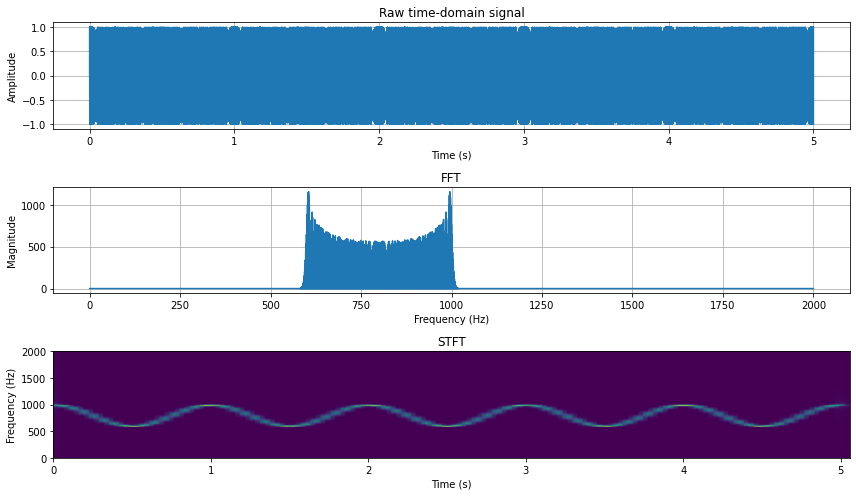

In [8]:
from scipy.signal import stft

fs = 4e3  # sampling frequency
f_mod = 1  # modulation frequency
f_delta = 200  # modulation depth
f0 = 800  # carrier frequency
T = 5  # signal duration
t = np.arange(0, T, 1/fs)  # time vector
x = np.sin(2*np.pi*t*f0 + f_delta/f_mod*np.sin(2*np.pi*t*f_mod))

fig, axes = plt.subplots(3, 1, figsize=(12, 7))

axes[0].plot(t, x)
axes[0].set_title('Raw time-domain signal')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

X = np.fft.rfft(x)
f = np.fft.rfftfreq(len(x), 1/fs)

axes[1].plot(f, abs(X))
axes[1].set_title('FFT')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude')

f, t, S = stft(x, fs, nperseg=512)

axes[2].pcolormesh(t, f, abs(S), shading='gouraud')
axes[2].set_title('STFT')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Frequency (Hz)')

fig.tight_layout()
plt.show()

FAQ
* *What if I still want to have a representation of my signal that depends only on frequency? E.g. if I am interested in the average energy in each frequency bin?*
    * You can still use the STFT and average the energy across frames! This is the Long-Term Average Spectrum (LTAS) and is a cleaner way to visualize the signal energy in each frequency bin.

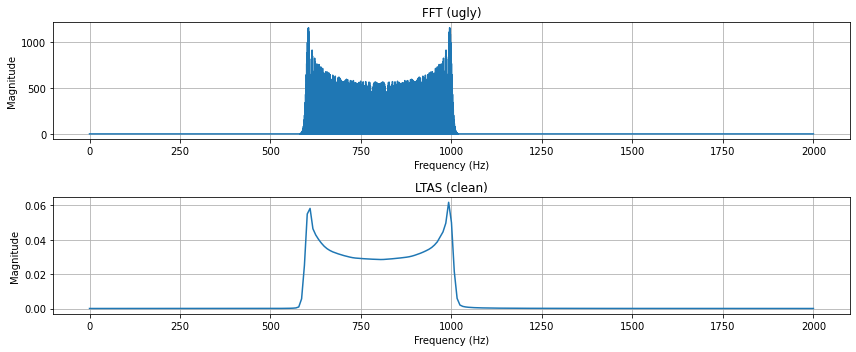

In [9]:
from scipy.signal import stft

fig, axes = plt.subplots(2, 1, figsize=(12, 5))

X = np.fft.rfft(x)
f = np.fft.rfftfreq(len(x), 1/fs)

axes[0].plot(f, abs(X))
axes[0].set_title('FFT (ugly)')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude')

f, t, S = stft(x, fs, nperseg=512)
LTAS = np.mean(abs(S), axis=1)

axes[1].plot(f, LTAS)
axes[1].set_title('LTAS (clean)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude')

fig.tight_layout()
plt.show()

* *But the magnitude (y-axis) does not match!*
    * There are different ways of normalizing the FFT and the STFT which are not always documented. Here the STFT implementation of `scipy` evidently applies a normalization whereas `np.fft.fft` does not. There is also windowing coming into play here which I didn't cover. Ultimately this does not matter so much as the most important is the location of the peaks and their relative difference.
* *How do I chose the length of the frame/window (`nperseg` argument)?*
    * This is up to you. A shorter frame size will give you a better time resolution, but a worse frequency resolution. Conversely a longer frame gives a worse time resolution, but a better frequency resolution. This is again the **time-frequency duality**. However the FFT is the fastest for signal lengths equal to a power of 2. So common frame sizes for audio analysis are e.g. 256, 512, 1024, 2048 or 4096, depending on the sampling rate. For other applications with different sampling rates, frame sizes must be adapted consequently.

# Filters

A filter is a system that performs mathematical operations on a signal in the time domain and outputs a new signal in the time domain.

Filters can be analog for continuous signals (electronic circuits consisting of capacitors and coils in e.g. a guitar amps or speaker crossover filters), or digital for discrete signals (integrated circuits). In this course we will only cover digital filters.

In DSP, filters are linear time-invariant (LTI) systems. Consider two digital signals $x[n]$ and $y[n]$ (note that $x[n]$ refers to the function $x$ of the discrete dependent variable $n$, and not the value taken by $x$ on a fixed $n$). A system $\mathcal{H}$ is an LTI system if it verifies the following properties:
* Linearity: $\forall\alpha,\beta\in\mathbb{R},\ \mathcal{H}(\alpha x[n]+\beta y[n])=\alpha\mathcal{H}(x[n])+\beta\mathcal{H}(y[n])$
    * Another way to write it is as follows: $\forall\alpha,\beta\in\mathbb{R},\ \mathcal{H}(\alpha x+\beta y)=\alpha\mathcal{H}(x)+\beta\mathcal{H}(y)$
* Time-invariance: $\forall m\in\mathbb{Z},\ \mathcal{H}(x[n-m])=\mathcal{H}(x)[n-m]$
    * Another way to write it is as follows: $\forall m\in\mathbb{Z},\ \mathcal{H}(n\mapsto x[n-m])=n\mapsto\mathcal{H}(x)[n-m]$
    * In other words, this means LTI systems do not change over time; if the input is delayed, the output is also delayed by the same amount.

In the following, $x[n]$ denotes the input of the filter, while $y[n]$ denotes the output of the filter.

![filter](pics/filter.png)

## Impulse response

A filter can be described by its **impulse response**. The impulse response is, as the name suggests, the output of the filter when presented a Dirac impulse $\delta[n]$,

$$ h[n] = \mathcal{H}(\delta[n]). $$

The reason why $h[n]$ describes the system follows. Since $\delta[n]$ is the identity element for the convolution, we have

$$
\begin{aligned}
y[n] &= \mathcal{H}(x[n]) \\
&= \mathcal{H}(x[n]*\delta[n]) && \delta\ \text{is the identity element}\\
&= \mathcal{H}\big(\sum_{m=-\infty}^{+\infty}x[m]\delta[n-m])\big)\\
&= \sum_{m=-\infty}^{+\infty}x[m]\mathcal{H}\big(\delta[n-m])\big) && \mathcal{H}\ \text{is linear}\\
&= \sum_{m=-\infty}^{+\infty}x[m]h[n-m] && \mathcal{H}\ \text{is time-invariant}\\
&= x[n]*h[n].
\end{aligned}
$$

This means that if we know $h[n]$, we can derive the output $y[n]$ from the filter given an arbitrary input $x[n]$ by realizing the convolution of $x[n]$ with $h[n]$.

## Difference equation

A digital filter can also be described by its difference equation:

$$ \sum_{m=0}^{N}a_my[n-m] = \sum_{m=0}^{M}b_mx[n-m], $$

or, if we want the output $y[n]$ isolated on the left side and assume $a_0=1$,

$$ y[n] = -\sum_{m=1}^{N}a_my[n-m] + \sum_{m=0}^{M}b_mx[n-m]. $$

* The $a_m$ are the **feedback coefficients** (similar to autoregressive coefficients in time series analysis)
* The $b_m$ are the **feedforward coefficients** (similar to moving-average coefficients in time series analysis)
* The **filter order** is $\max(M, N)$

Note that we usually force $a_0=1$. If it's not the case we can simply normalize all the coefficients by $a_0$ without changing the filter behavior.

**Examples:**

* L-point moving average filter:

$$ y[n] = \frac{1}{L}(x[n]+x[n-1]+...+x[n-L+1]). $$

  Here $a_0=1$ and $b_m=\frac{1}{L}$ for $m\in\{0, 1, ..., L-1\}$. The filter order is $L-1$.

* Exponential smoothing with smoothing factor $0<\alpha<1$:

$$ y[n] = \alpha y[n-1] + (1-\alpha)x[n]. $$

  Here $a_0=1$, $a_1=-\alpha$ and $b_0=1-\alpha$. The filter order is 1.

## Finite Impulse Response (FIR) filter

If there are no feedback coefficients (except $a_0$), then the filter is an **FIR filter**,

$$ y[n] = \sum_{m=0}^{M}b_mx[n-m]. $$

FIR filters are very **stable**, but computationally more **expensive**.

The impulse response of an FIR filter $\mathcal{H}$ is

$$
\begin{aligned}
h[n] &= \mathcal{H}(\delta[n]) \\
&= \sum_{m=0}^{M}b_m\delta[n-m] \\
&= b_n.
\end{aligned}$$

Therefore the impulse response of an FIR filter is simply the sequence of feedforward coefficients: $h[n]=[b_0, b_1,...,b_M]$.

**Example**: The L-point moving average filter is an FIR filter. Its impulse response is $h[n]=[\frac{1}{L}, \frac{1}{L}, ..., \frac{1}{L}]$.

## Infinite Impulse Response (IIR) filter

If there is at least one feedback coefficient (other than $a_0$), then the filter is an **IIR filter**,

$$ y[n] = -\sum_{m=1}^{N}a_my[n-m] + \sum_{m=0}^{M}b_mx[n-m]. $$

IIR filters can be **unstable**, but are computationally much **cheaper**.

The impulse response of an IIR cannot be explicitly written; it is infinite.

**Example**: The exponential smoothing filter is an IIR filter,

$$ y[n] = \alpha y[n-1] + (1-\alpha)x[n]. $$

Trying to write the impulse response would look like this,

$$
\begin{aligned}
h[n] &= \mathcal{H}(\delta[n]) \\
&= \alpha\mathcal{H}(\delta[n-1]) + (1-\alpha)\delta[n] \\
&= \alpha^2\mathcal{H}(\delta[n-2]) + \alpha(1-\alpha)\delta[n-1] + (1-\alpha)\delta[n] \\
&= \alpha^3\mathcal{H}(\delta[n-3]) + \alpha^2(1-\alpha)\delta[n-2] + \alpha(1-\alpha)\delta[n-1] + (1-\alpha)\delta[n] \\
&=\ ...
\end{aligned}$$

As you can see this would never end. Also if $\alpha>1$, the output would explode and the filter would be unstable.

**Example**:

Digital filtering is implemented under `scipy.signal.lfilter`. The function takes as arguments the sequence of feedforward coefficients, the sequence of feedback coefficients and the input signal. Note the first feedforward coefficient, i.e. $a_0$, must be 1.

Below I filter a noisy signal with a moving average filter and an exponential smoothing filter using `scipy.signal.lfilter`.

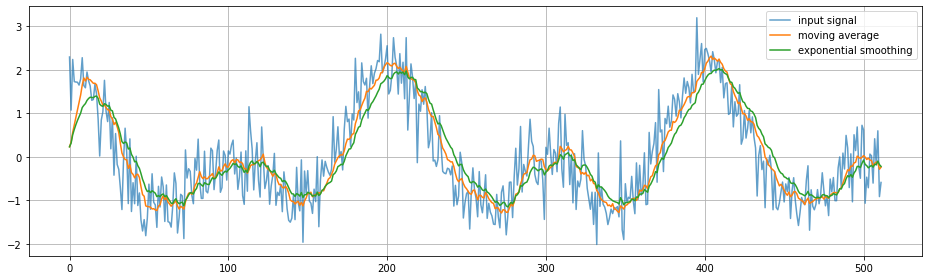

In [10]:
from scipy.signal import lfilter

# an arbitrary noisy input signal
n = 512  # signal length
x = 0.5*np.random.randn(n) + np.cos(2*np.pi*np.arange(n)*0.01) + np.cos(2*np.pi*np.arange(n)*0.005)

# moving average filter
L = 10  # number of points to average
b = np.ones(L)/L  # feedforward coefficients
a = [1]  # feedback coefficients
y1 = lfilter(b, a, x)

# exponential smoothing filter
alpha = 0.9
b = [1-alpha]  # feedforward coefficients
a = [1, -alpha]  # feedback coefficients
y2 = lfilter(b, a, x)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(x, label='input signal', alpha=0.7)
ax.plot(y1, label='moving average')
ax.plot(y2, label='exponential smoothing')
ax.legend()
fig.tight_layout()
plt.show()

## Filter frequency response

We saw above that a filter can be characterized with the impulse response; filtering is the same as convolving with the impulse response of the filter. The convolution theorem tells us that a convolution in the time domain is the same as multiplication in the frequency domain. Therefore, we can perform a filtering operation in the frequency domain instead, by multiplying the Fourier transform of the input signal with the Fourier transform of the impulse response,

$$ y[n]=h[n]*x[n]\quad\xrightarrow{\quad\text{DTFT}\quad}\quad Y(\omega)=H(\omega)X(\omega) $$

$H(\omega)$ is the frequency response of the filter. It's another description of the filter, this time in the frequency domain. It describes how each frequency component is modified in gain and phase.

Another way to look at it is as follows. Consider a **FIXED** $\omega\in\mathbb{R}$, and $x[n]=e^{i\omega n}$. That is, $x[n]$ is a digital signal consisting of a single pure tone (single complex exponential, single component) at frequency $\omega$. The output of the filter is then

$$
\begin{aligned}
y[n] &= h[n]*x[n] \\
&= \sum_{m=-\infty}^{\infty}h[m]x[n-m] \\
&= \sum_{m=-\infty}^{\infty}h[m]e^{i\omega(n-m)} \\
&= e^{i\omega n}\sum_{m=-\infty}^{\infty}h[m]e^{-i\omega m} \\
&= e^{i\omega n}\ \text{DTFT}(h[n]) \\
&= e^{i\omega n}H(\omega) \\
&= x[n]H(\omega) \\
\end{aligned}
$$

**Note**: This time, $H(\omega)$ refers to the value taken by $H$ on the fixed $\omega$, and not the function $H$ of the dependent variable $\omega$. This is why I emphasized on $\omega$ being fixed previously. $x[n]$ is still referring to the function $x$ though.

As we can see, the pure tone $x[n]$ is simply multiplied by $H(\omega)$. Since $H(\omega)$ is complex, this means $x[n]$ is transformed both in magnitude and in phase. In other words, the output is also a pure tone at the same frequency, only scaled and shifted. If we now instead consider an arbitrary input and think of it as an infinite sum of complex exponentials at different frequencies, and we remember filters are linear systems, then the output is simply the sum of all the components individually scaled and shifted according to the function $H(\omega)$. Which is why a description like $H(\omega)$ is so powerful. Beautiful, isn't it?

* *But what if the filter is an IIR filter? For an FIR filter, $H(\omega)$ can be obtained by calculating the DTFT of the impulse response, which is simply the sequence of feedforward coefficients. But for an IIR, the impulse response is infinite!*

We can still define the frequency response as follows. We saw above that if $x[n]=e^{i\omega n}$, then $y[n]=e^{i\omega n}H(\omega)$. Thus, starting from the difference equation,

$$
\begin{aligned}
&& &\sum_{m=0}^{N}a_my[n-m] = \sum_{m=0}^{M}b_mx[n-m] \\
&&\implies &\sum_{m=0}^{N}a_me^{i\omega (n-m)}H(\omega) = \sum_{m=0}^{M}b_me^{i\omega (n-m)} \\
&&\implies &H(\omega)e^{i\omega n}\sum_{m=0}^{N}a_me^{-i\omega m} = e^{i\omega n}\sum_{m=0}^{M}b_me^{-i\omega m} \\
&&\implies &H(\omega)=\frac{\sum_{m=0}^{M}b_me^{-i\omega m}}{\sum_{m=0}^{N}a_me^{-i\omega m}} \\
\end{aligned}
$$

Note that if there are no feedback coefficients except $a_0=1$ (case of an FIR filter), then only the numerator remains, and we correctly obtain the DTFT of the sequence of feedforward coefficients (assuming $b_m=0$ for $m \notin \{0,1,...,M\}$ so the sum extends to infinity)!

**Example**:

A filter frequency response can be calculated using `scipy.signal.freqz`. The function takes as arguments the sequence of feedforward coefficients and the sequence of feedback coefficients. It can also take the number of evenly-spaced frequency points `worN` at which to calculate the frequency response. The function outputs a frequency vector and the complex frequency response. Note the frequency vector ranges from 0 to $\pi$, so you then have to scale it so that it ranges from $0$ to $\frac{f_s}{2}$, depending on the sampling frequency $f_s$ you are working at. Or you can provide the `fs` argument to `scipy.signal.freqz` and the frequency vector output will be correctly scaled.

Let's calculate the frequency responses of the moving average and the exponential smoothing filters.

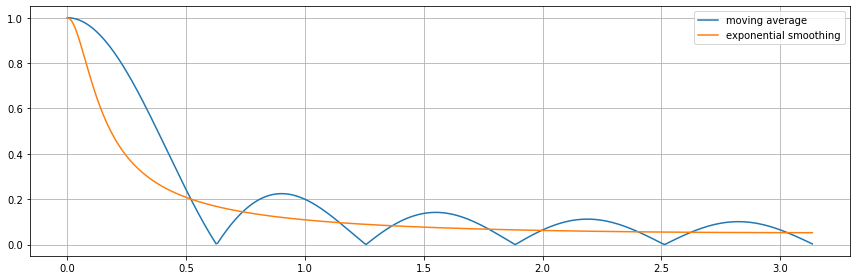

In [11]:
from scipy.signal import freqz

# moving average filter
L = 10  # number of points to average
b = np.ones(L)/L  # feedforward coefficients
a = [1]  # feedback coefficients
w1, h1 = freqz(b, a)

# exponential smoothing filter
alpha = 0.9
b = [1-alpha]  # feedforward coefficients
a = [1, -alpha]  # feedback coefficients
w2, h2 = freqz(b, a)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(w1, abs(h1), label='moving average')
ax.plot(w2, abs(h2), label='exponential smoothing')
ax.legend()
fig.tight_layout()
plt.show()

We can see both filters act as low-pass filters. They present a high gain that is close to 1 at low frequencies, and the gain decreases as the frequency increases. This means the filter attenuates high frequencies, while it lets the low frequencies pass through. This makes sense, as a moving-average filter smooths out the fast and noisy fluctuations, which are high frequencies. Same can be said about the exponential filter.

FAQ:
* Can I use `np.fft.fft` instead of `scipy.signal.freqz` to plot the frequency response?
    * Yes, but no. Yes because `scipy.signal.freqz` uses `np.fft.fft` inside it and you can technically obtain the correct result after cropping the negative frequencies from the output of `np.fft.fft`, provided you provide a sufficient number of points `n` to `np.fft.fft`. But don't do it. `scipy.signal.freqz` is meant specifically for filters; it takes coefficients `b` and `a` as arguments and outputs a one-sided, well-defined frequency response. Using `scipy.signal.freqz` for a filter shows you are understanding what is happening.
* Can I use `scipy.signal.freqz` to plot a signal spectrum?
    * **NOOOOOOO**. `scipy.signal.freqz` plots a **frequency response**. A signal presents a **spectrum**, not a frequency response. A filter is a **system**, it takes signals as input/output and thus presents a **frequency response**, not a spectrum. Filter = frequency response, signal = spectrum. If you use `scipy.signal.freqz` to plot the frequency content of a signal, you are clearly showing you are not understanding this subtlety. In practice what would happen if you use `scipy.signal.freqz` for a signal is, since signal lengths are generally much larger than the number of frequency bins `worN` we wish to analyze (`worN` is 512 by default), the signal would be cropped and only the first `worN` samples would be analyzed! So for signal spectrums, please use `scipy.signal.stft` and average the energy across time-frames (see LTAS above), or use `np.fft.fft` on the whole signal if you are too lazy.

# Postface

I tried to cover here some fundamental DSP aspects in the quickest possible way, with an emphasis on practical implementation in Python. There are tons of other important subjects I didn't cover, like
* window functions
* spectral leakage
* filter design
* biquad filters
* Z-transform
* power spectral density

but it would take me too long, and I need to stop myself at some point. Nonetheless the subjects mentioned above are good leads if you are interested in knowing more about DSP.

If you find typos, I would greatly appreciate it if you reported them ❤️.

# References

* Alan V. Oppenheim, Ronald W. Schafer and John R. Buck. *Discrete-time signal processing* (2nd ed.). Prentice Hall, 1999.
* John G. Proakis and Dimitris G. Manolakis. *Introduction to Digital Signal Processing : Principles, Algorithms and Applications* (4th ed.). Pearson Prentice Hall, 2007.
* [Sascha Spors, Digital Signal Processing - Lecture notes featuring computational examples.](https://nbviewer.jupyter.org/github/spatialaudio/digital-signal-processing-lecture/blob/master/index.ipynb)
* Lecture notes on [22001 Acoustic signal processing](https://kurser.dtu.dk/course/22001) by Tobias May at DTU